# Explore anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## Scores arr to df

In [4]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        print(f"Loading score: {score_name}")

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'

    return scores_df


## RES-iduals

## fine grained

In [5]:
def res_residual(spec, spec_rec):

    flux_diff_sq = np.abs(spec - spec_rec)**2
    flux_factor = flux_diff_sq / np.abs(spec + 0.001)
    
    return flux_factor

### figure

In [35]:
def fig_RESidual(
    wave, wave_ticks, wave_lims,
    spec, rec_spec,
    flux_ticks, flux_lims,
    residual,
    res_ticks, res_lims,
    alpha = 0.5,
    figsize=(20, 9)
):

    fig, axs = plt.subplots(
        2, 1,
        sharex=True,
        figsize=figsize
    )
    # ----------------------------------------------------
    axs[0].plot(
        wave, spec,
        color="black", label="Original"
    )
    axs[0].plot(
        wave, rec_spec,
        color="red", alpha=alpha, label="Reconstruction"
    )

    if flux_ticks is False:
        pass
    else:
        axs[0].set_yticks(flux_ticks)
    
    if flux_lims is False:
        pass
    else:
        f_min, f_max = flux_lims
        axs[0].set_ylim(f_min, f_max)
    # ----------------------------------------------------
    # Residulas
    axs[1].plot(
        wave, residual,
        color="black", label="Residuals"
    )

    if res_ticks is False:
        pass
    else:
        axs[1].set_yticks(res_ticks)

    if res_lims is False:
        pass
    else:
        res_min, res_max = res_lims 
        axs[1].set_ylim(res_min, res_max)

    # ----------------------------------------------------
    # labels
    axs[0].legend(
        loc='upper left',
        frameon=False,
        ncol=2
    )
    axs[1].legend(loc='upper left', frameon=False)

    # ----------------------------------------------------

    # wavelengt setup
    if wave_lims is False:
        pass
    else: 
        w_min, w_max = wave_lims
        axs[1].set_xlim(w_min, w_max)

    if wave_ticks is False:
        pass
    else:
        axs[1].set_xticks(wave_ticks)

    # set minor ticks on
    for ax in axs.flatten(): ax.minorticks_on()
    # axe labels
    # x
    axs[1].set_xlabel(r"$\lambda$ [nm]")
    # y
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("RES-iduals")

    return fig, axs


## Score name map

In [6]:
def map_score_name(score):
    """Maps score code names to more readable names."""
    if score == 'mse':
        return 'SE'
    elif score == 'mse_filter_250':
        return 'Filtered SE'
    elif score == 'mse_97':
        return 'Trimmed SE'
    elif score == 'mse_filter_250_97':
        return 'Filtered + Trimmed SE'
    
    elif score == 'mse_rel':
        return 'RSE'
    elif score == 'mse_filter_250_rel':
        return 'Filtered RSE'
    elif score == 'mse_97_rel':
        return 'Trimmed RSE'
    elif score == 'mse_filter_250_97_rel':
        return 'Filtered + Trimmed RSE'
    else:
        return score

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


## Model

In [9]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

## Scores

In [11]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

In [22]:
score_rank_df[['rank_mse_rel', 'mse_rel']].sort_values(by='mse_rel', ascending=False).head(5)

,rank_mse_rel,mse_rel
specobjid,,
305239577747023872,1.0,24.499810
2830625680629196800,2.0,24.441423
2830685054257096704,3.0,24.168451
734111514142730240,4.0,23.134280
3240467000396376064,5.0,22.655893


# RES

## Rank 1

rank_mse_rel                    1.0
rank_mse_filter_250_rel        16.0
rank_mse_97_rel               197.0
rank_mse_filter_250_97_rel    274.0
rank_mse                        8.0
rank_mse_filter_250            12.0
rank_mse_97                   237.0
rank_mse_filter_250_97        397.0
Name: 305239577747023872, dtype: float64

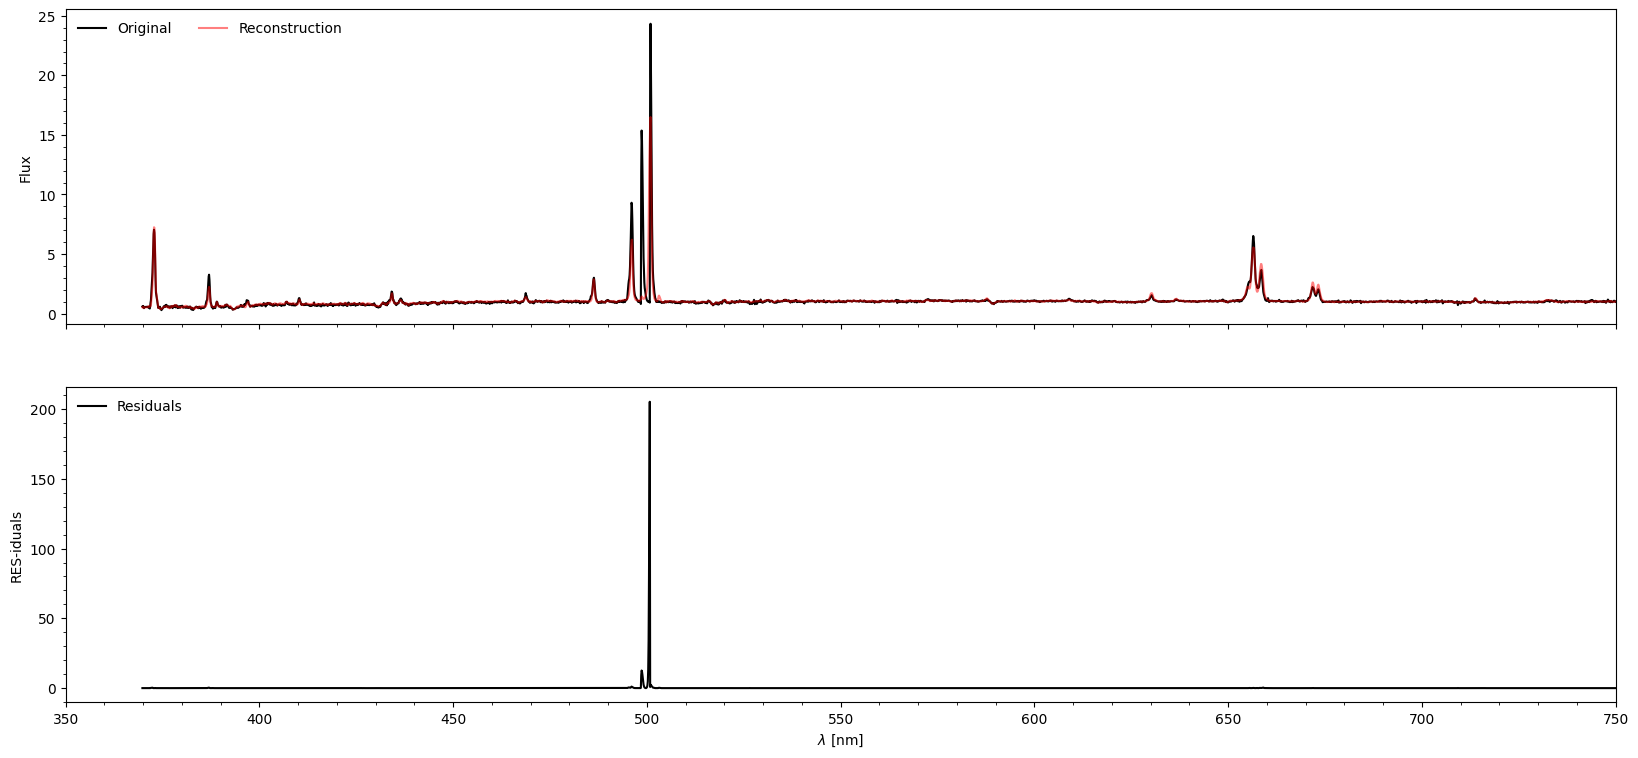

In [89]:
bad_id = 305239577747023872	
idx_bad = specobjid_to_idx(bad_id, idx_id_spec)
bad_spec = spectra[idx_bad]
rec_bad_spec = ae_model.reconstruct(bad_spec)[0]
residual_bad = res_residual(bad_spec, rec_bad_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    spec=bad_spec, rec_spec=rec_bad_spec,
    flux_ticks=False, flux_lims=False,
    residual=residual_bad,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[bad_id, rse_rank_cols + se_rank_cols].T

## Rank 8

rank_mse_rel                      8.0
rank_mse_filter_250_rel        2631.0
rank_mse_97_rel                3507.0
rank_mse_filter_250_97_rel    11625.0
rank_mse                         17.0
rank_mse_filter_250             479.0
rank_mse_97                    1280.0
rank_mse_filter_250_97         3189.0
Name: 788189345310861312, dtype: float64

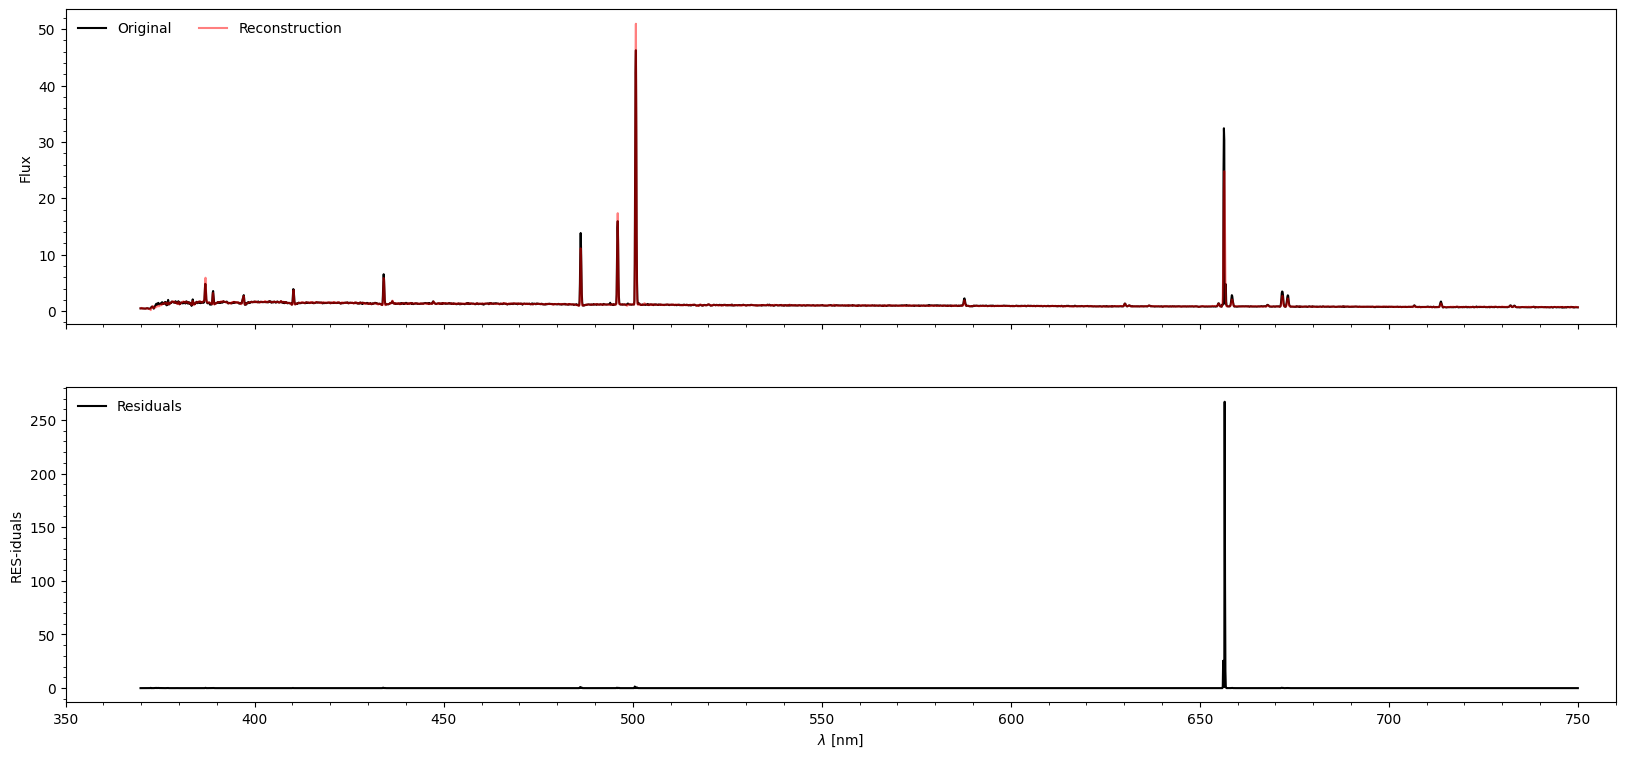

In [94]:
mask = score_rank_df.rank_mse_rel == 8
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 760),
    # wave_lims=(655, 658),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False,
    flux_lims=False,
    # flux_lims=(0, 3),
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 9

rank_mse_rel                     9.0
rank_mse_filter_250_rel       2129.0
rank_mse_97_rel               3442.0
rank_mse_filter_250_97_rel    4845.0
rank_mse                        53.0
rank_mse_filter_250            260.0
rank_mse_97                   1453.0
rank_mse_filter_250_97        1960.0
Name: 2374624116784261120, dtype: float64

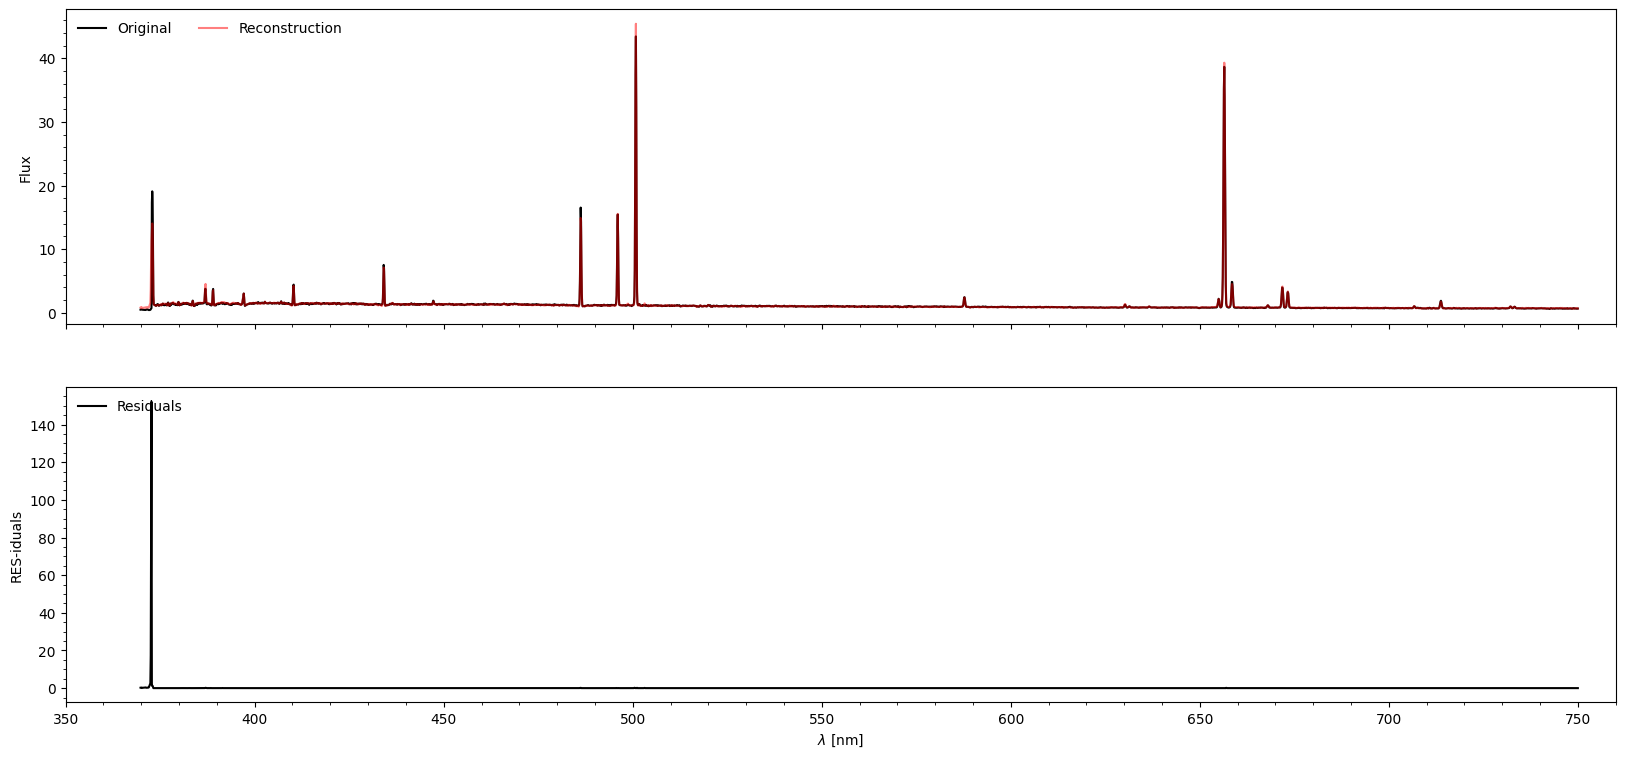

In [99]:
mask = score_rank_df.rank_mse_rel == 9
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 760),
    # wave_lims=(369, 375),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False,
    flux_lims=False,
    # flux_lims=(0, 3),
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 13

rank_mse_rel                     13.0
rank_mse_filter_250_rel       61415.0
rank_mse_97_rel               84654.0
rank_mse_filter_250_97_rel    98218.0
rank_mse                         54.0
rank_mse_filter_250           11133.0
rank_mse_97                   34232.0
rank_mse_filter_250_97        49378.0
Name: 2936445988153354240, dtype: float64

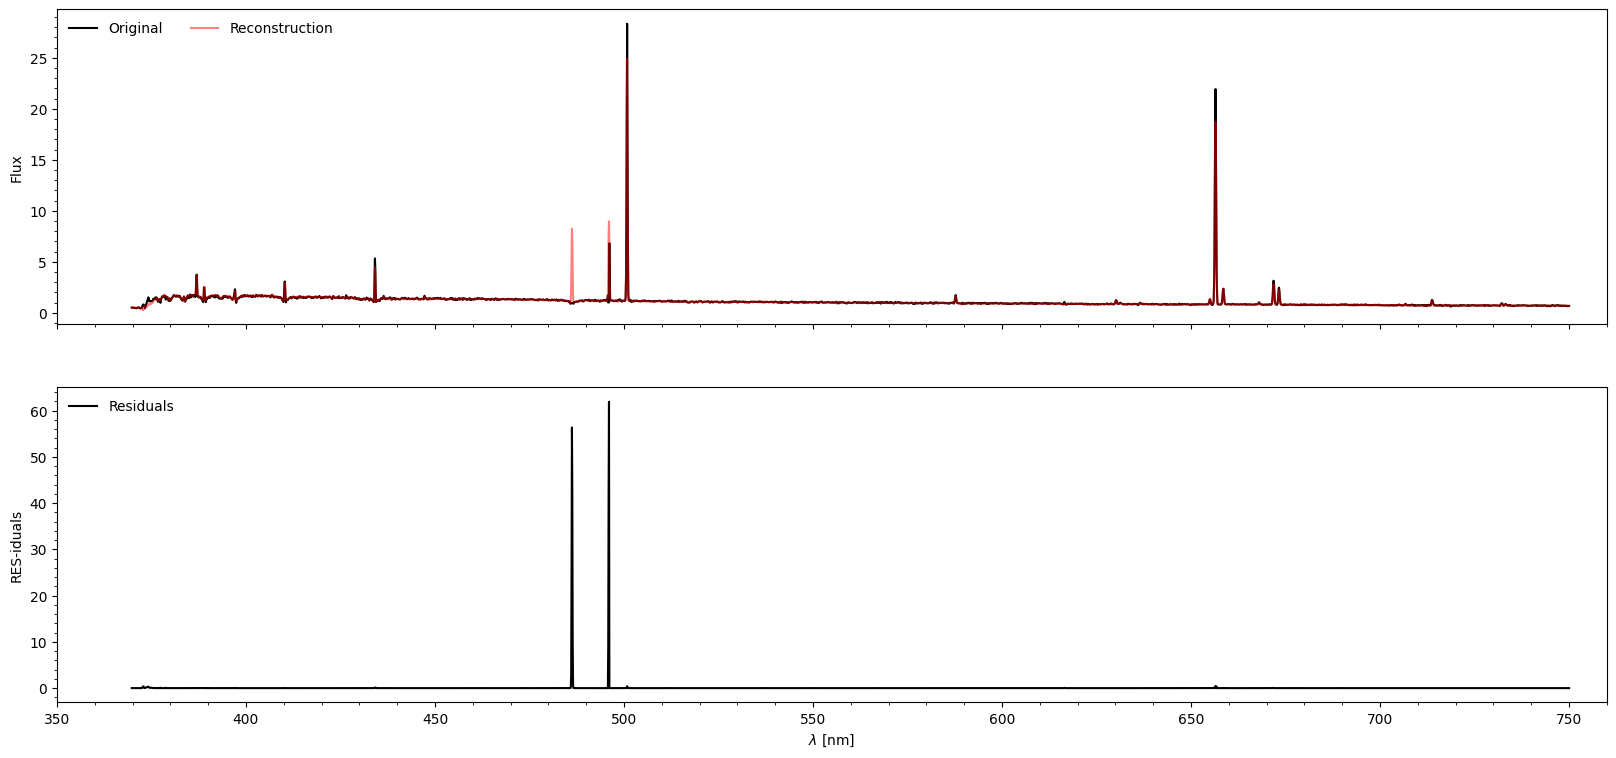

In [98]:
mask = score_rank_df.rank_mse_rel == 13
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 760),
    # wave_lims=(369, 375),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False,
    flux_lims=False,
    # flux_lims=(0, 3),
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 41

rank_mse_rel                     41.0
rank_mse_filter_250_rel       16289.0
rank_mse_97_rel                9704.0
rank_mse_filter_250_97_rel    16799.0
rank_mse                        105.0
rank_mse_filter_250            1717.0
rank_mse_97                    4554.0
rank_mse_filter_250_97         6583.0
Name: 1947945710867474432, dtype: float64

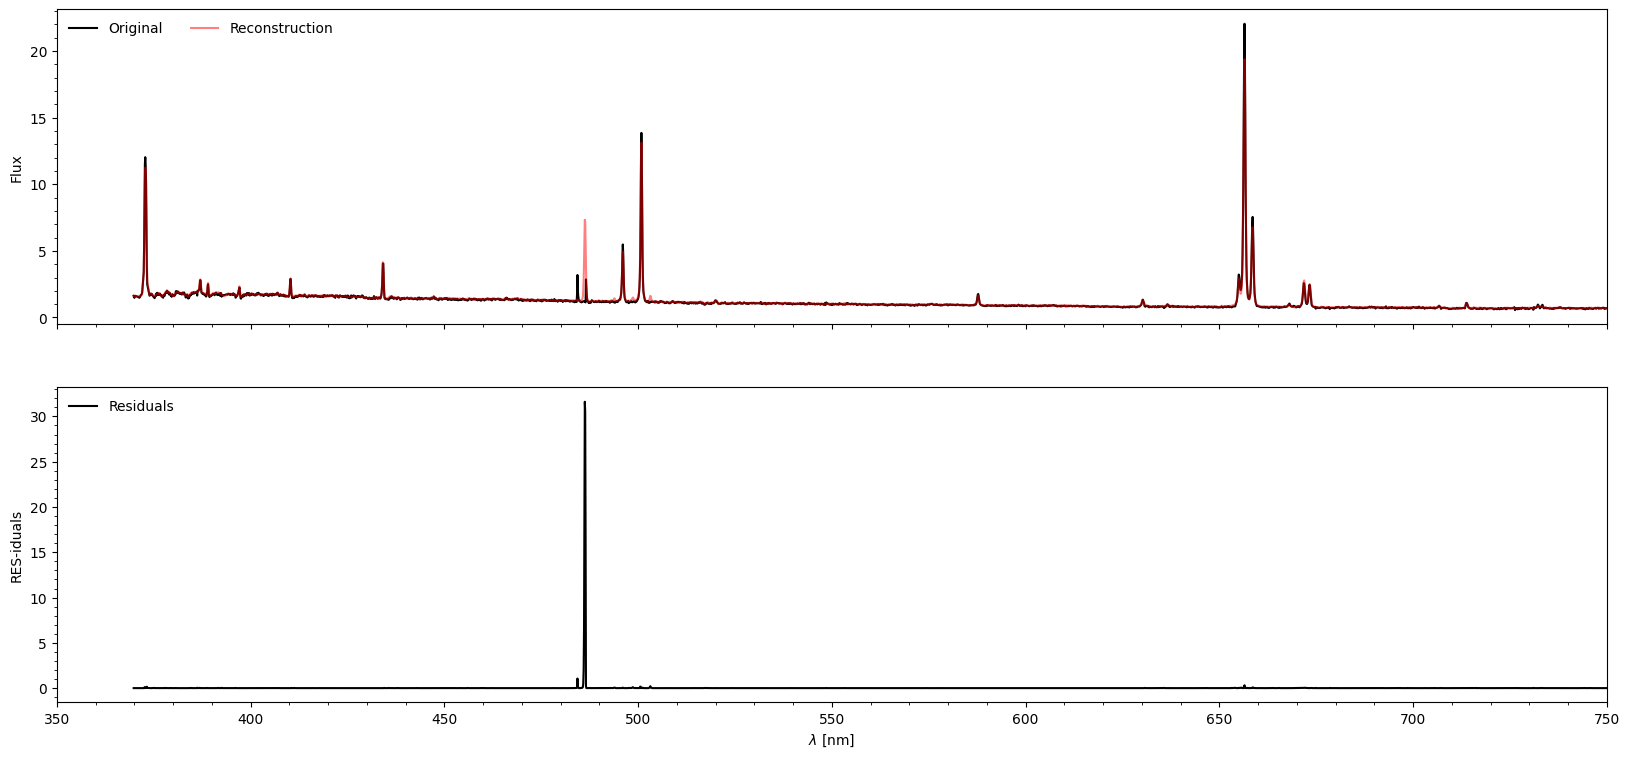

In [101]:
mask = score_rank_df.rank_mse_rel == 41
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(350, 380),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 47

rank_mse_rel                    47.0
rank_mse_filter_250_rel       5527.0
rank_mse_97_rel               2347.0
rank_mse_filter_250_97_rel    1853.0
rank_mse                       151.0
rank_mse_filter_250           4001.0
rank_mse_97                   1216.0
rank_mse_filter_250_97        1102.0
Name: 3348509962874677248, dtype: float64

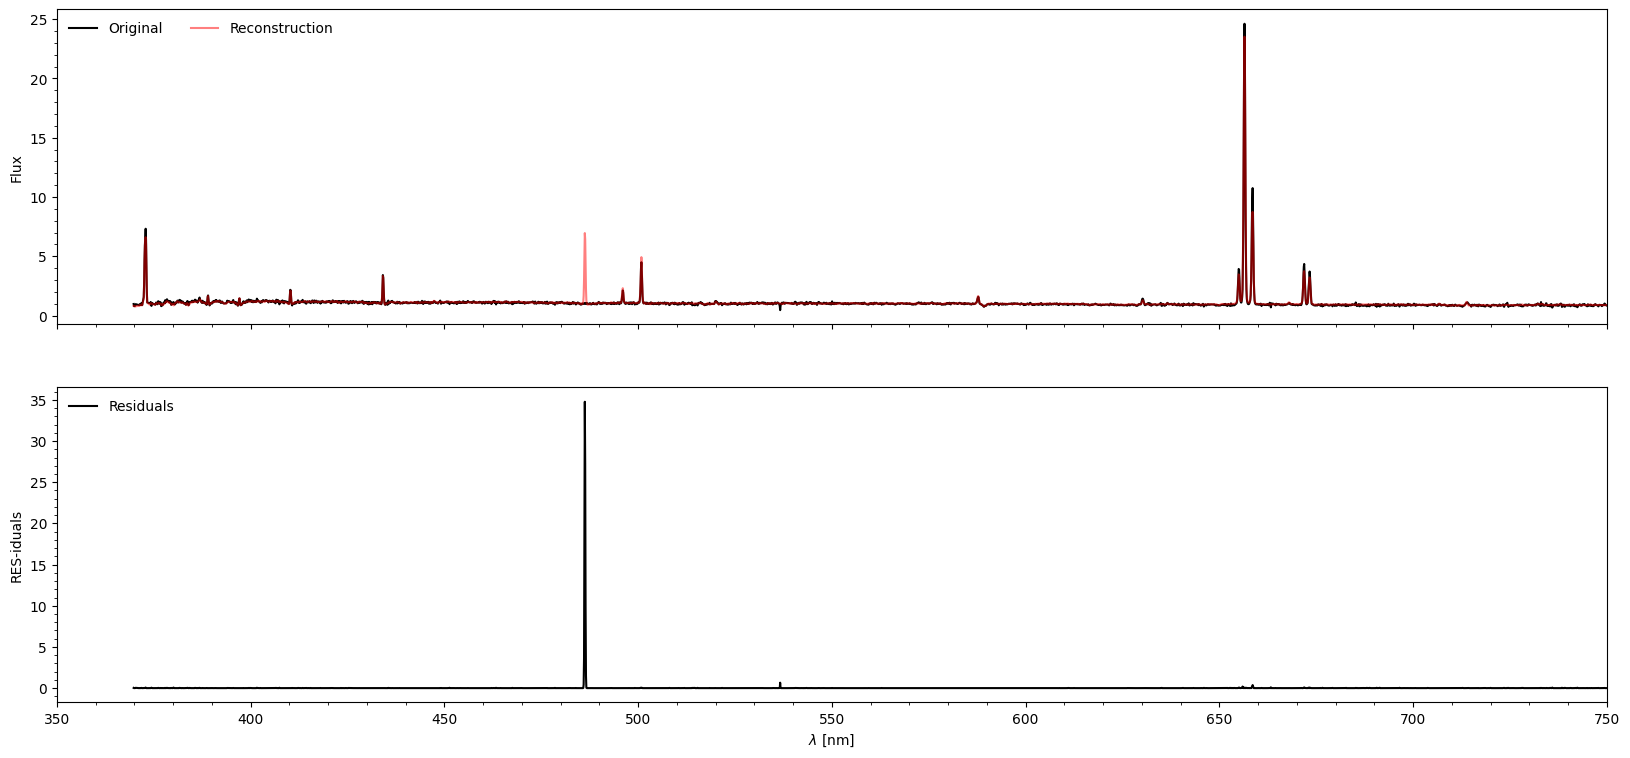

In [102]:
mask = score_rank_df.rank_mse_rel == 47
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 170

rank_mse_rel                   170.0
rank_mse_filter_250_rel       4922.0
rank_mse_97_rel               1918.0
rank_mse_filter_250_97_rel    3232.0
rank_mse                       170.0
rank_mse_filter_250           2447.0
rank_mse_97                   1028.0
rank_mse_filter_250_97        1750.0
Name: 551793516175452160, dtype: float64

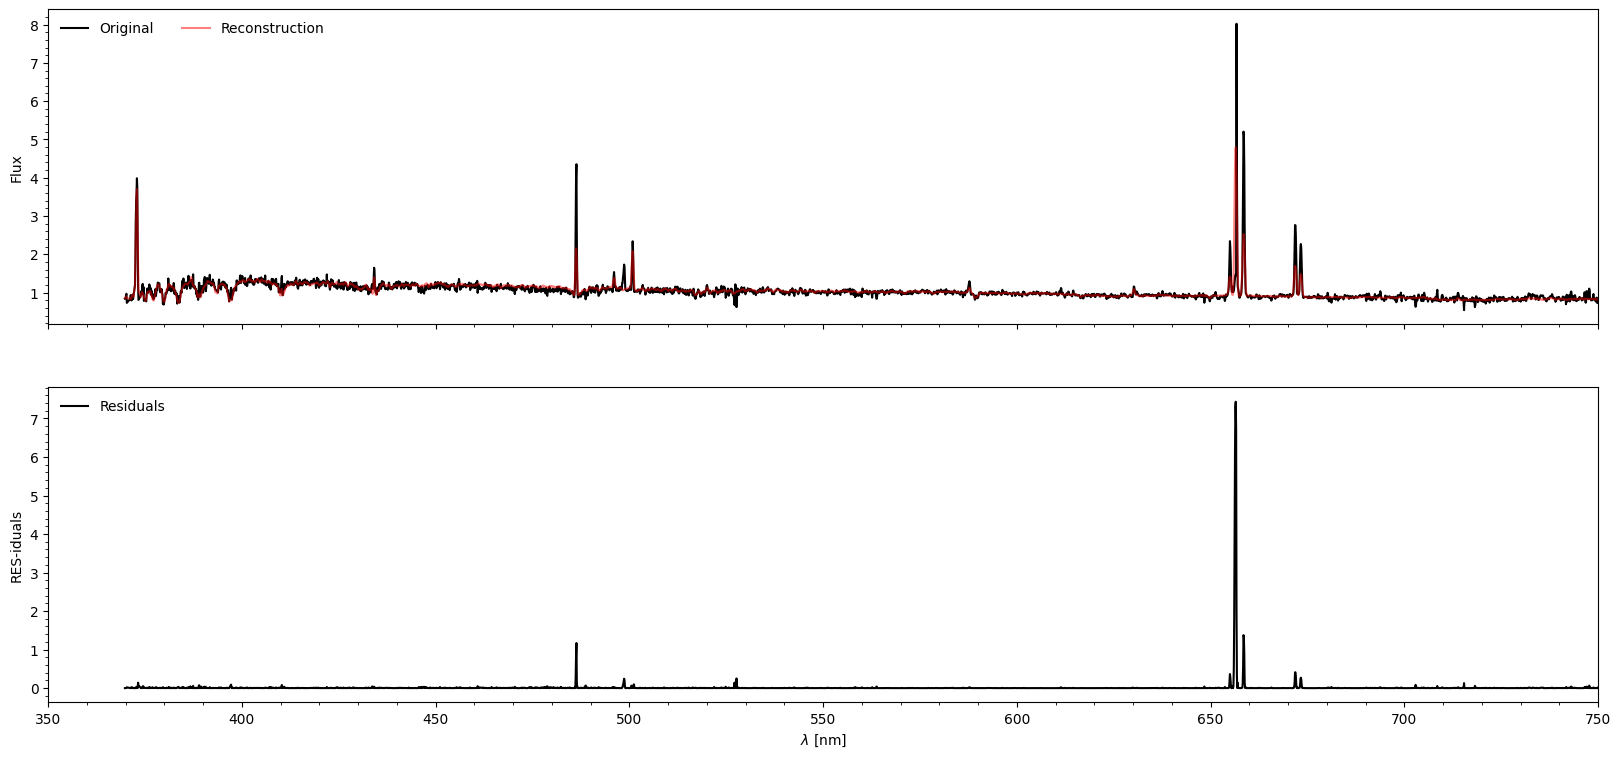

In [112]:
mask = score_rank_df.rank_mse_rel == 170
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 307

rank_mse_rel                    307.0
rank_mse_filter_250_rel        2381.0
rank_mse_97_rel                4279.0
rank_mse_filter_250_97_rel    20287.0
rank_mse                        327.0
rank_mse_filter_250             765.0
rank_mse_97                    1837.0
rank_mse_filter_250_97         5651.0
Name: 2262016816106727424, dtype: float64

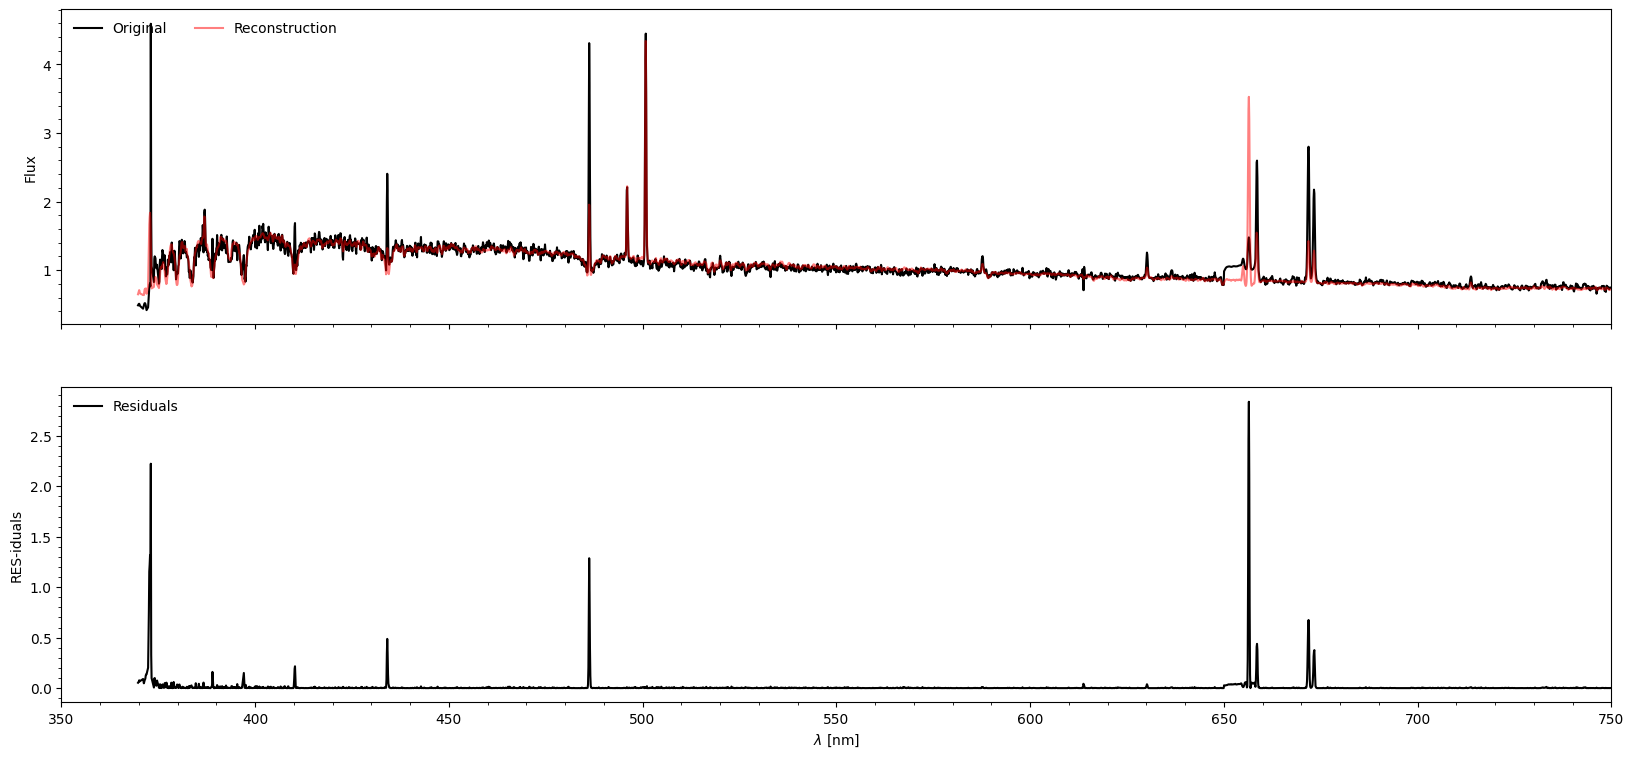

In [118]:
mask = score_rank_df.rank_mse_rel == 307
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 322

rank_mse_rel                    322.0
rank_mse_filter_250_rel        6737.0
rank_mse_97_rel                6483.0
rank_mse_filter_250_97_rel    16610.0
rank_mse                        272.0
rank_mse_filter_250            2141.0
rank_mse_97                    9918.0
rank_mse_filter_250_97        15866.0
Name: 2345358688836937728, dtype: float64

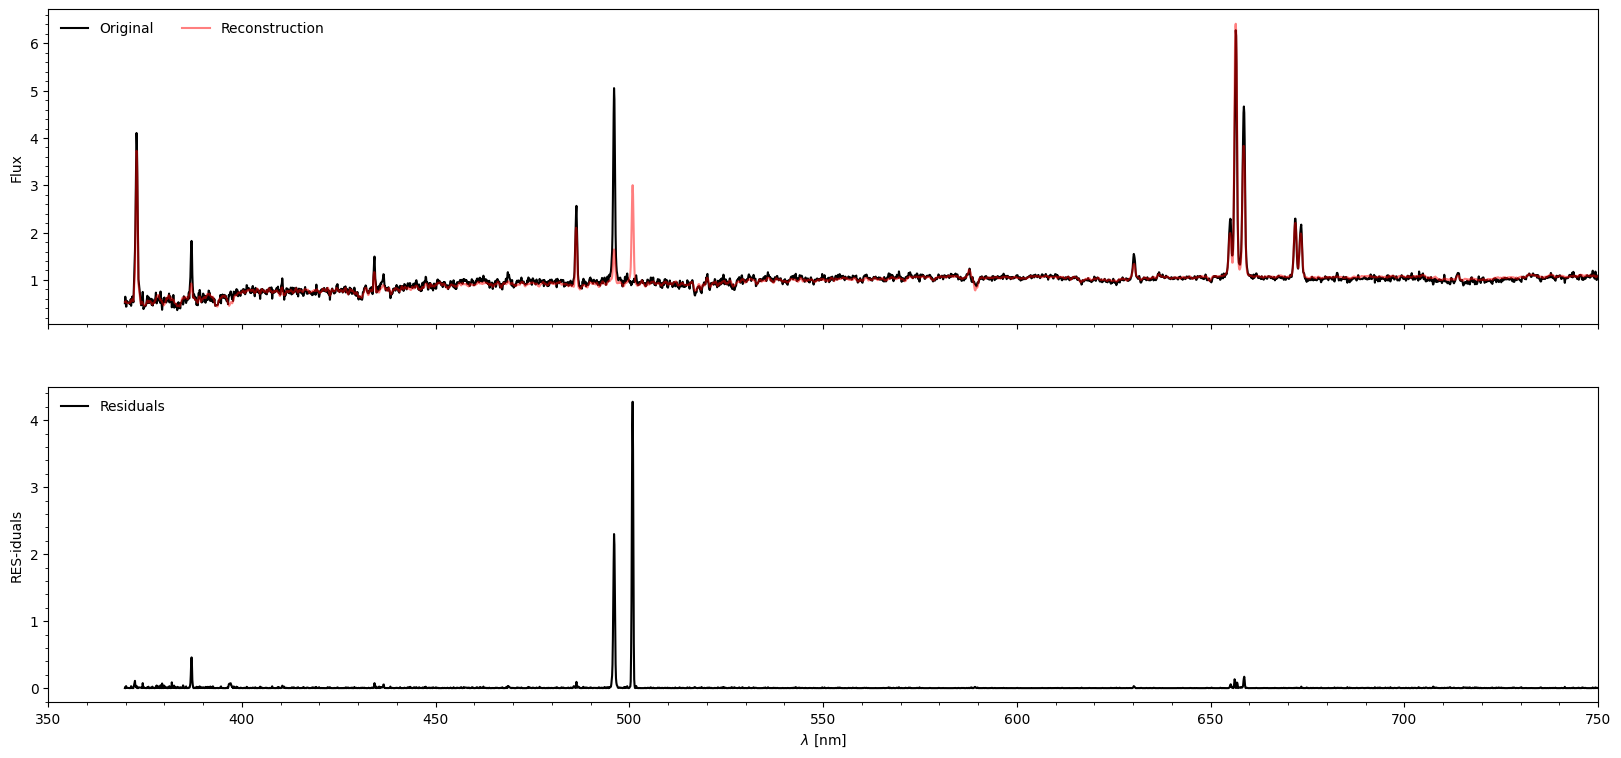

In [119]:
mask = score_rank_df.rank_mse_rel == 322
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 550

rank_mse_rel                    550.0
rank_mse_filter_250_rel        3053.0
rank_mse_97_rel               11131.0
rank_mse_filter_250_97_rel    36758.0
rank_mse                        391.0
rank_mse_filter_250             898.0
rank_mse_97                    7588.0
rank_mse_filter_250_97        17169.0
Name: 862452560479414272, dtype: float64

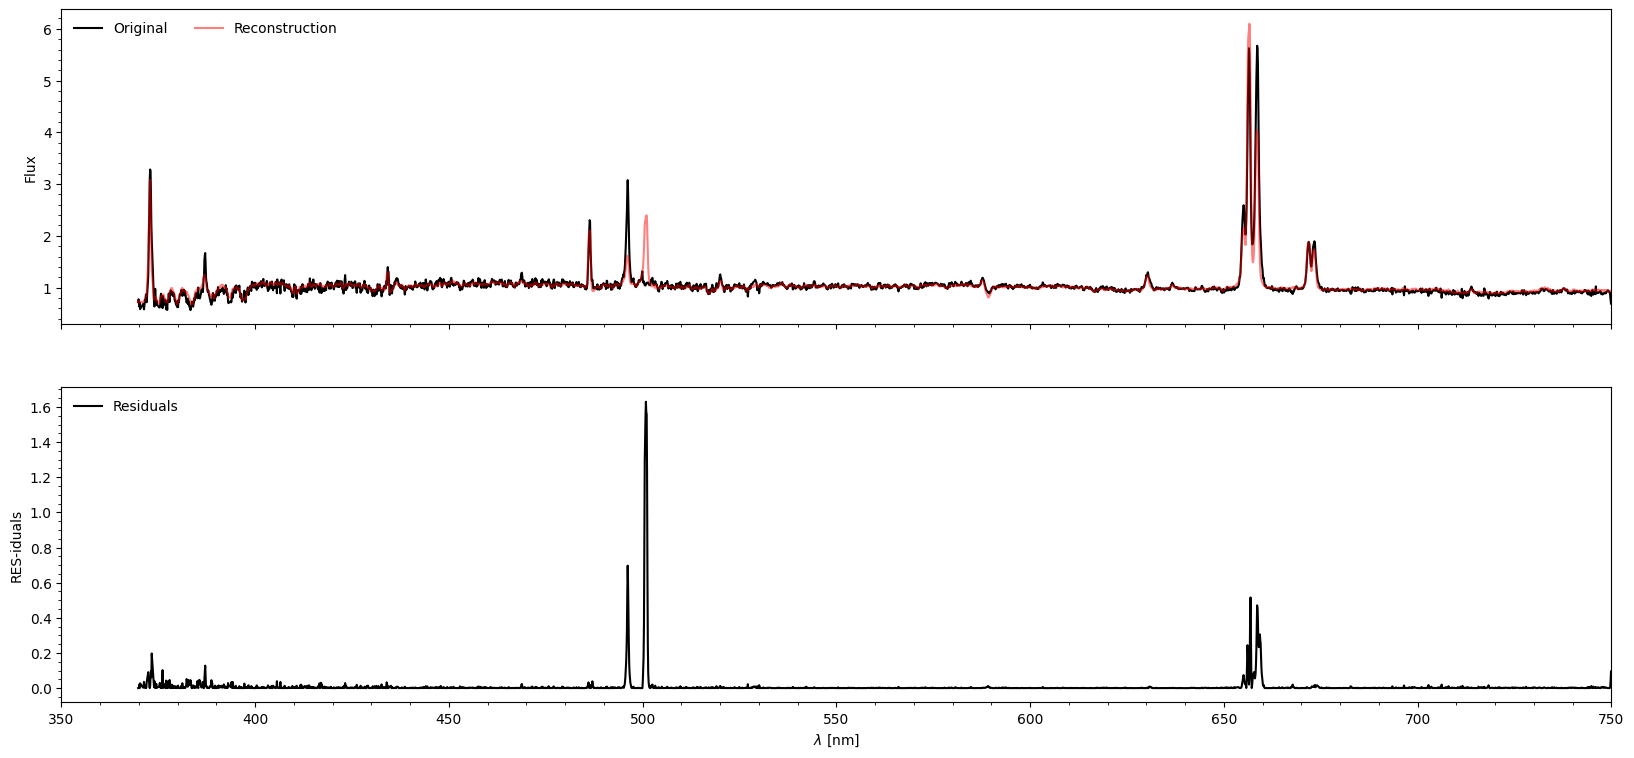

In [121]:
mask = score_rank_df.rank_mse_rel == 550
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 552

rank_mse_rel                   552.0
rank_mse_filter_250_rel       3733.0
rank_mse_97_rel               6025.0
rank_mse_filter_250_97_rel    8599.0
rank_mse                       397.0
rank_mse_filter_250           1395.0
rank_mse_97                   2265.0
rank_mse_filter_250_97        4981.0
Name: 2402682835736487936, dtype: float64

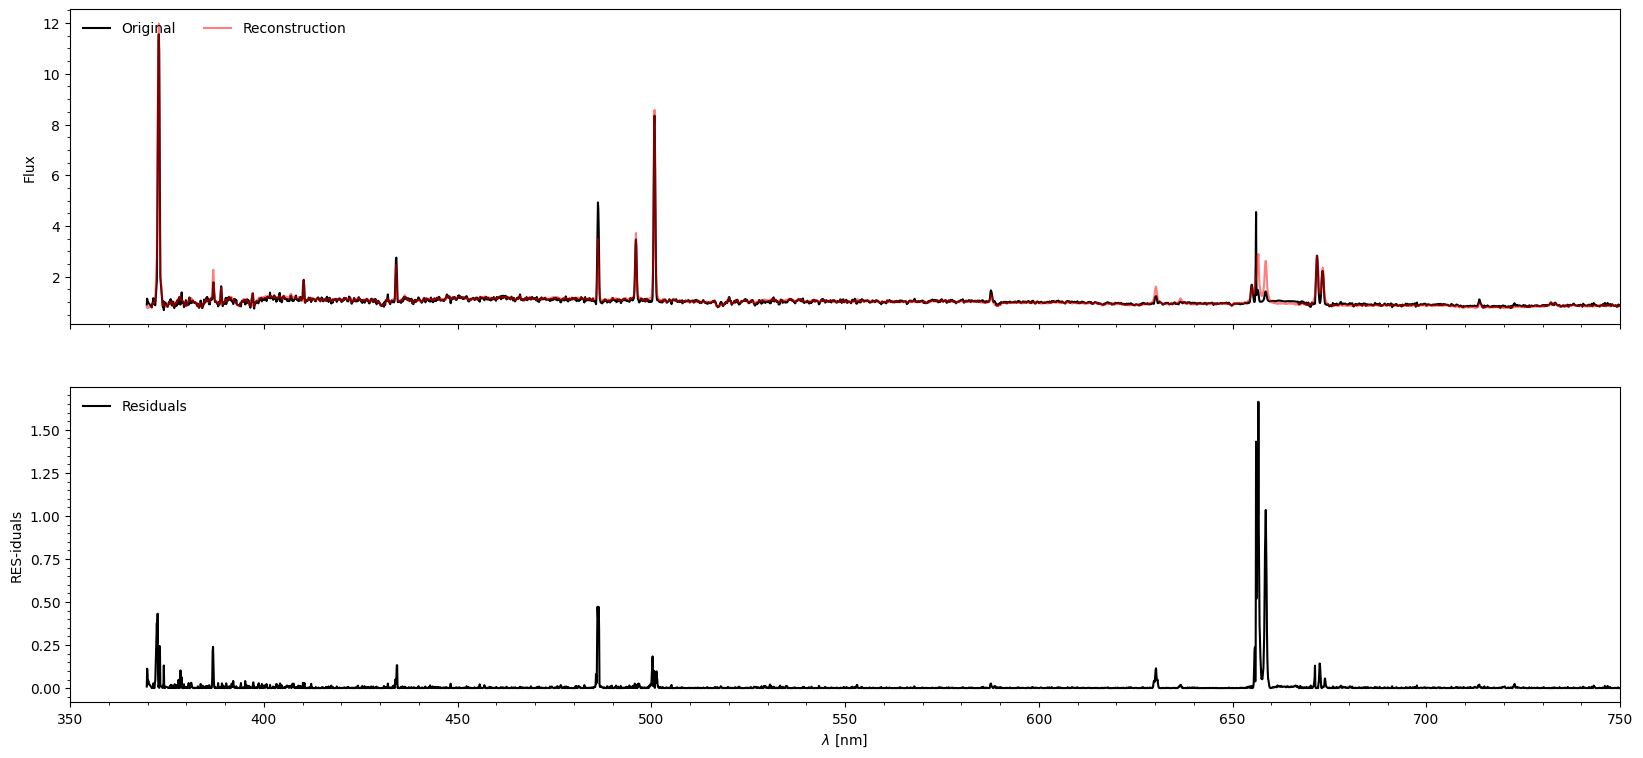

In [122]:
mask = score_rank_df.rank_mse_rel == 552
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 797

rank_mse_rel                    797.0
rank_mse_filter_250_rel       26383.0
rank_mse_97_rel               15534.0
rank_mse_filter_250_97_rel     9811.0
rank_mse                        722.0
rank_mse_filter_250           30350.0
rank_mse_97                   20572.0
rank_mse_filter_250_97        19729.0
Name: 1111414708109338624, dtype: float64

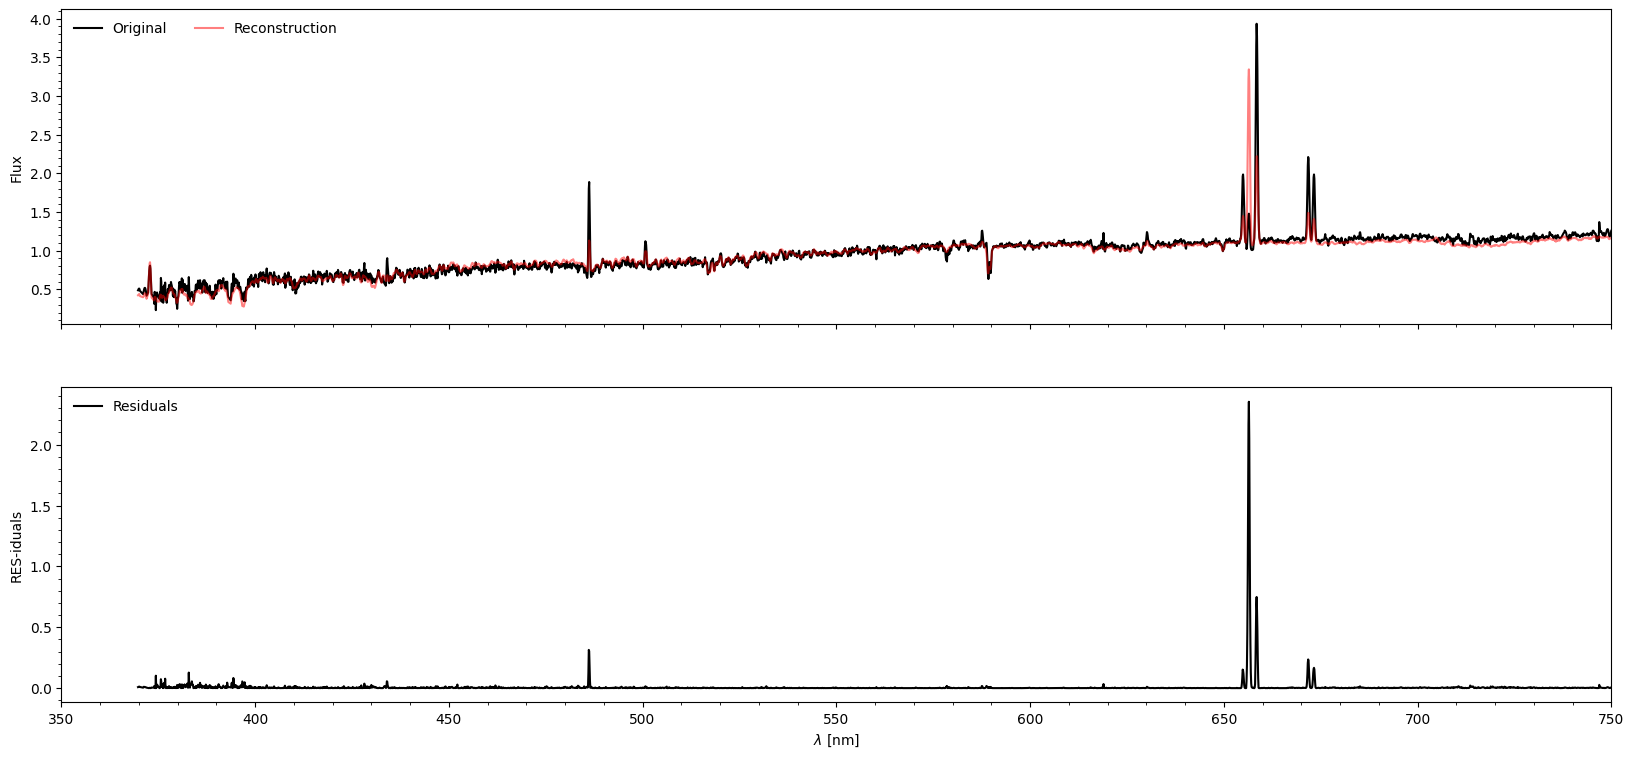

In [125]:
mask = score_rank_df.rank_mse_rel == 797
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 856

rank_mse_rel                    856.0
rank_mse_filter_250_rel        2526.0
rank_mse_97_rel               11240.0
rank_mse_filter_250_97_rel    23758.0
rank_mse                       1223.0
rank_mse_filter_250            3125.0
rank_mse_97                   13424.0
rank_mse_filter_250_97        17626.0
Name: 628398147059607552, dtype: float64

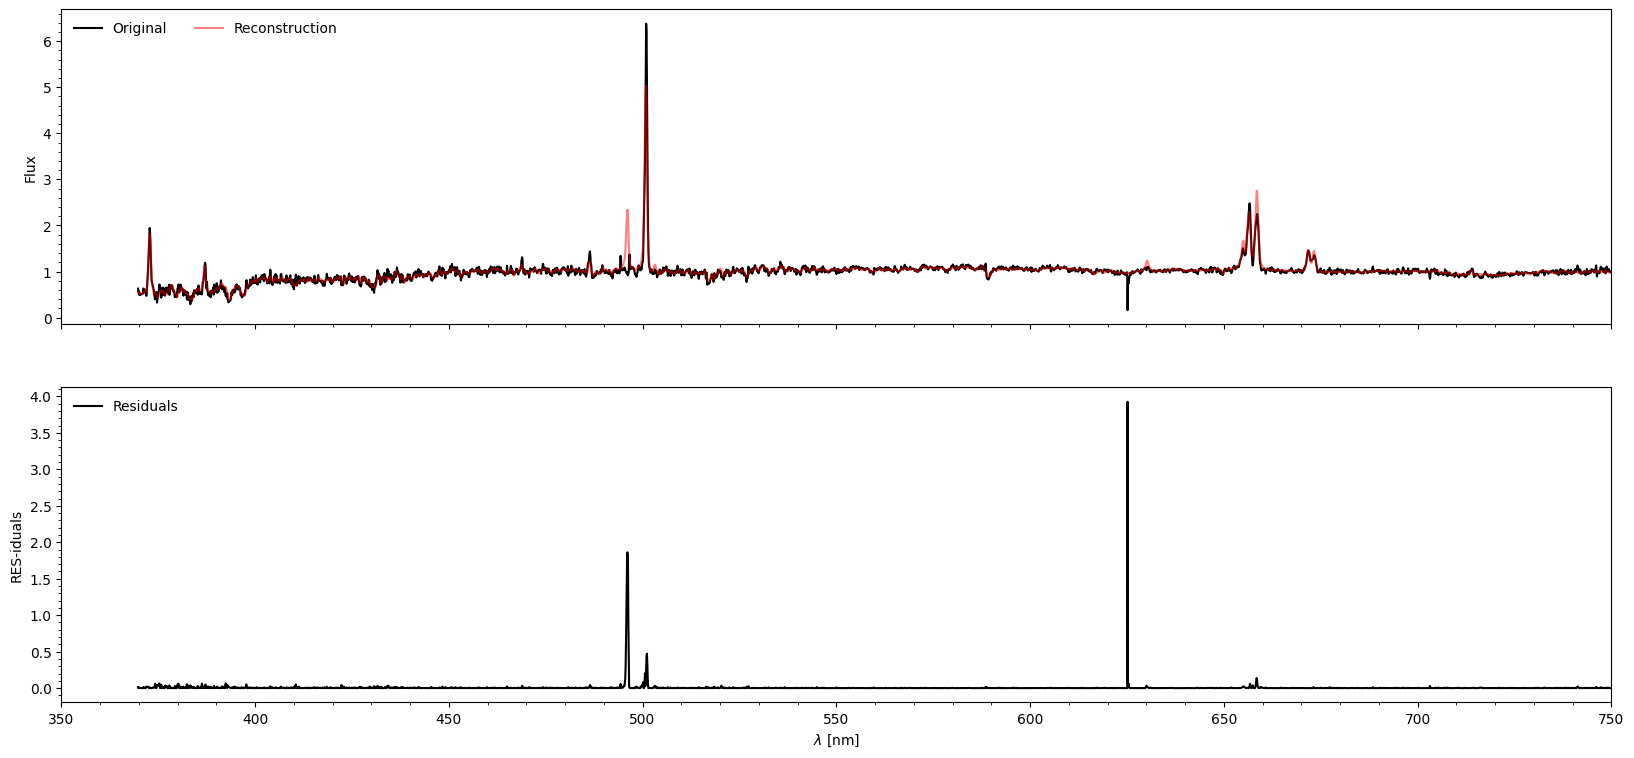

In [126]:
mask = score_rank_df.rank_mse_rel == 856
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 911

rank_mse_rel                     911.0
rank_mse_filter_250_rel         9131.0
rank_mse_97_rel               145157.0
rank_mse_filter_250_97_rel    161481.0
rank_mse                         425.0
rank_mse_filter_250             7880.0
rank_mse_97                   130764.0
rank_mse_filter_250_97        148582.0
Name: 1882639117586556928, dtype: float64

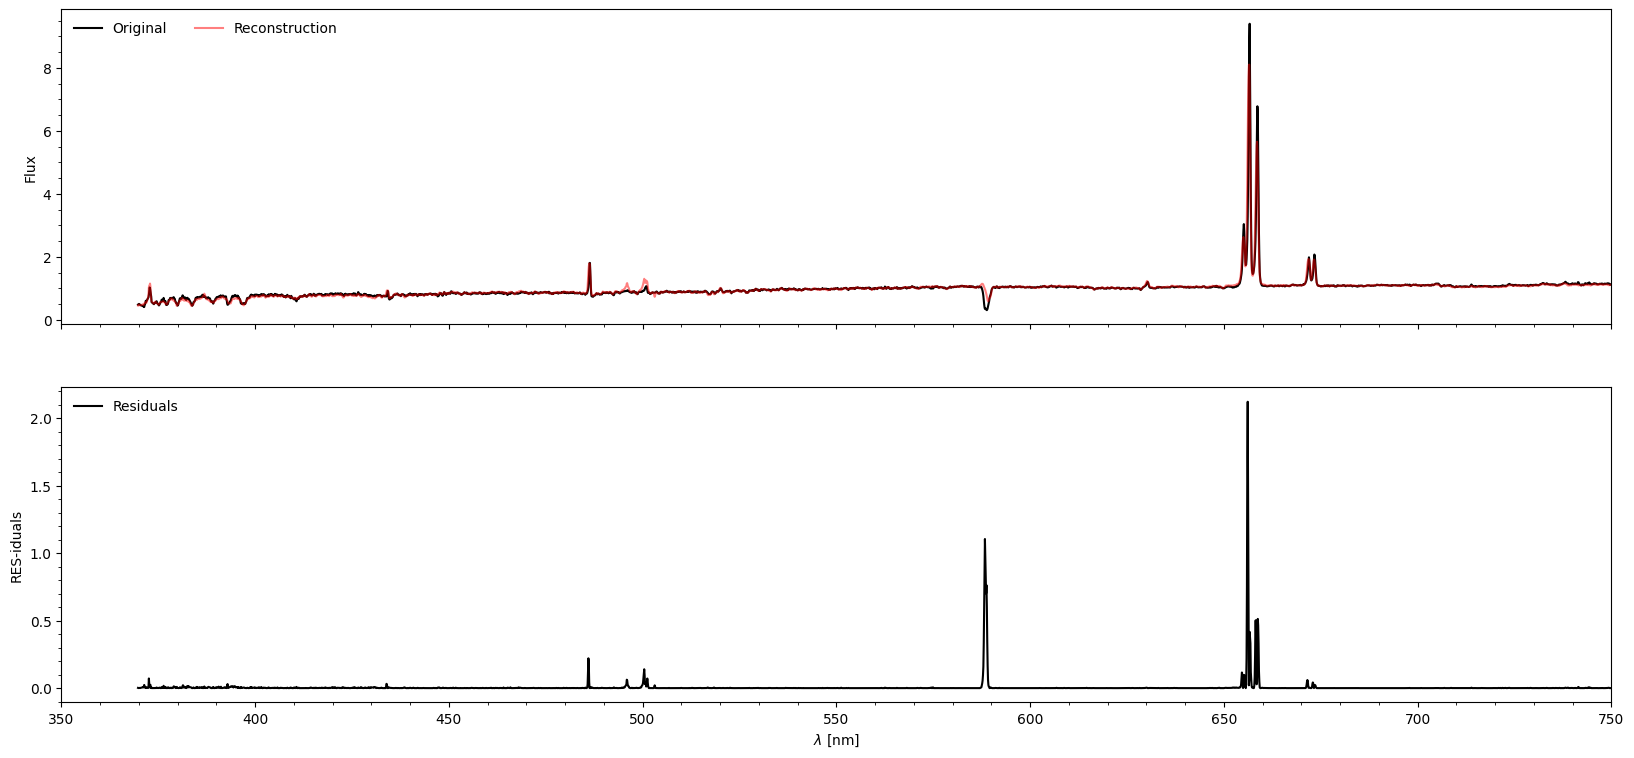

In [127]:
mask = score_rank_df.rank_mse_rel == 911
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

# Filter RES

## Rank 890

rank_mse_rel                   1897.0
rank_mse_filter_250_rel         890.0
rank_mse_97_rel               10328.0
rank_mse_filter_250_97_rel    12055.0
rank_mse                       3675.0
rank_mse_filter_250            2024.0
rank_mse_97                    5237.0
rank_mse_filter_250_97         3601.0
Name: 2032375840699869184, dtype: float64

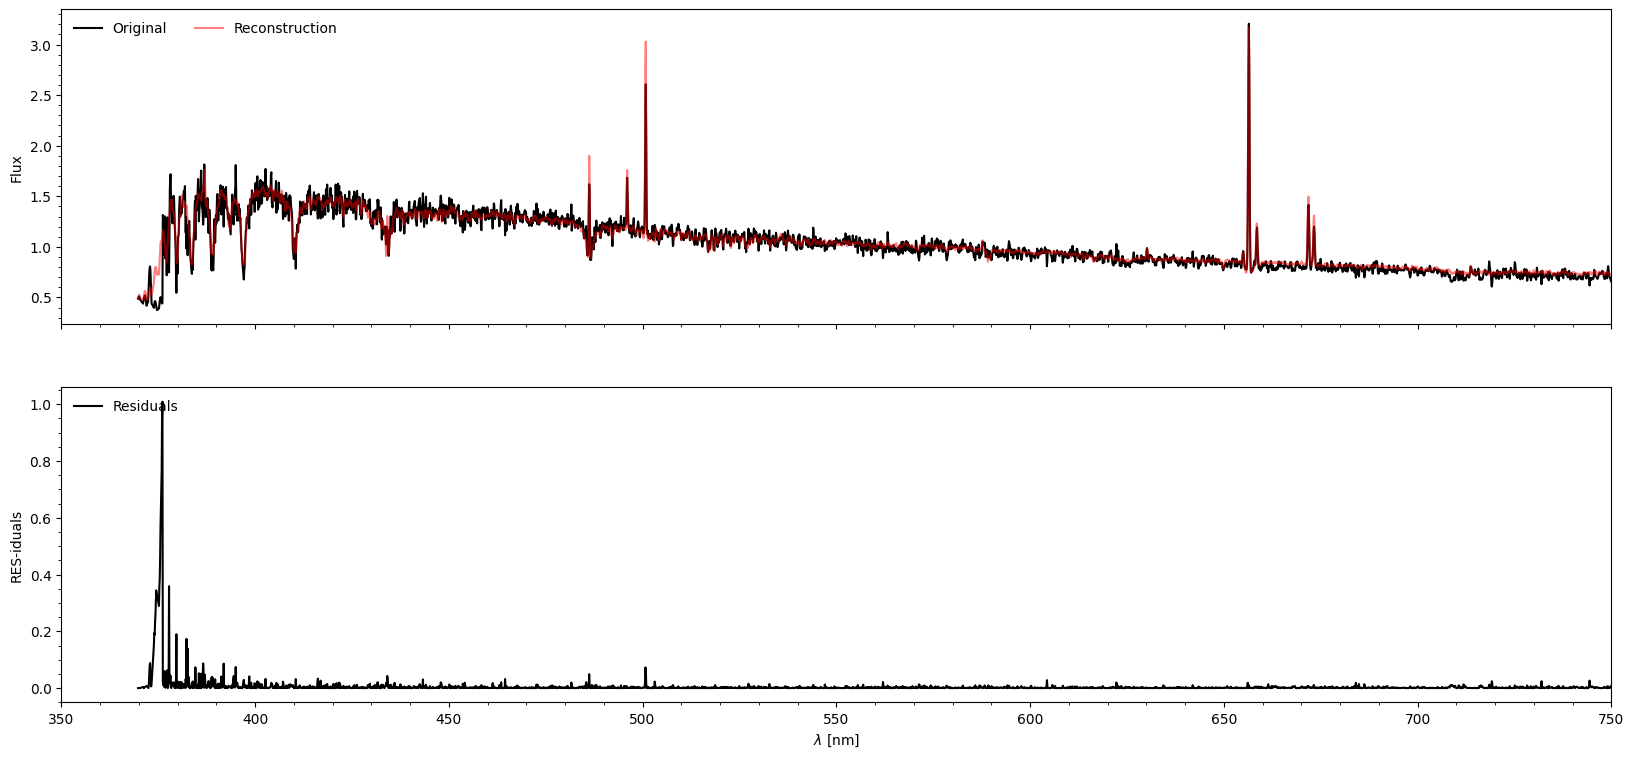

In [140]:
mask = score_rank_df.rank_mse_filter_250_rel == 890
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 1236

rank_mse_rel                   1826.0
rank_mse_filter_250_rel        1236.0
rank_mse_97_rel               21106.0
rank_mse_filter_250_97_rel    25893.0
rank_mse                       3563.0
rank_mse_filter_250            1630.0
rank_mse_97                   15518.0
rank_mse_filter_250_97        16296.0
Name: 2399358736251512832, dtype: float64

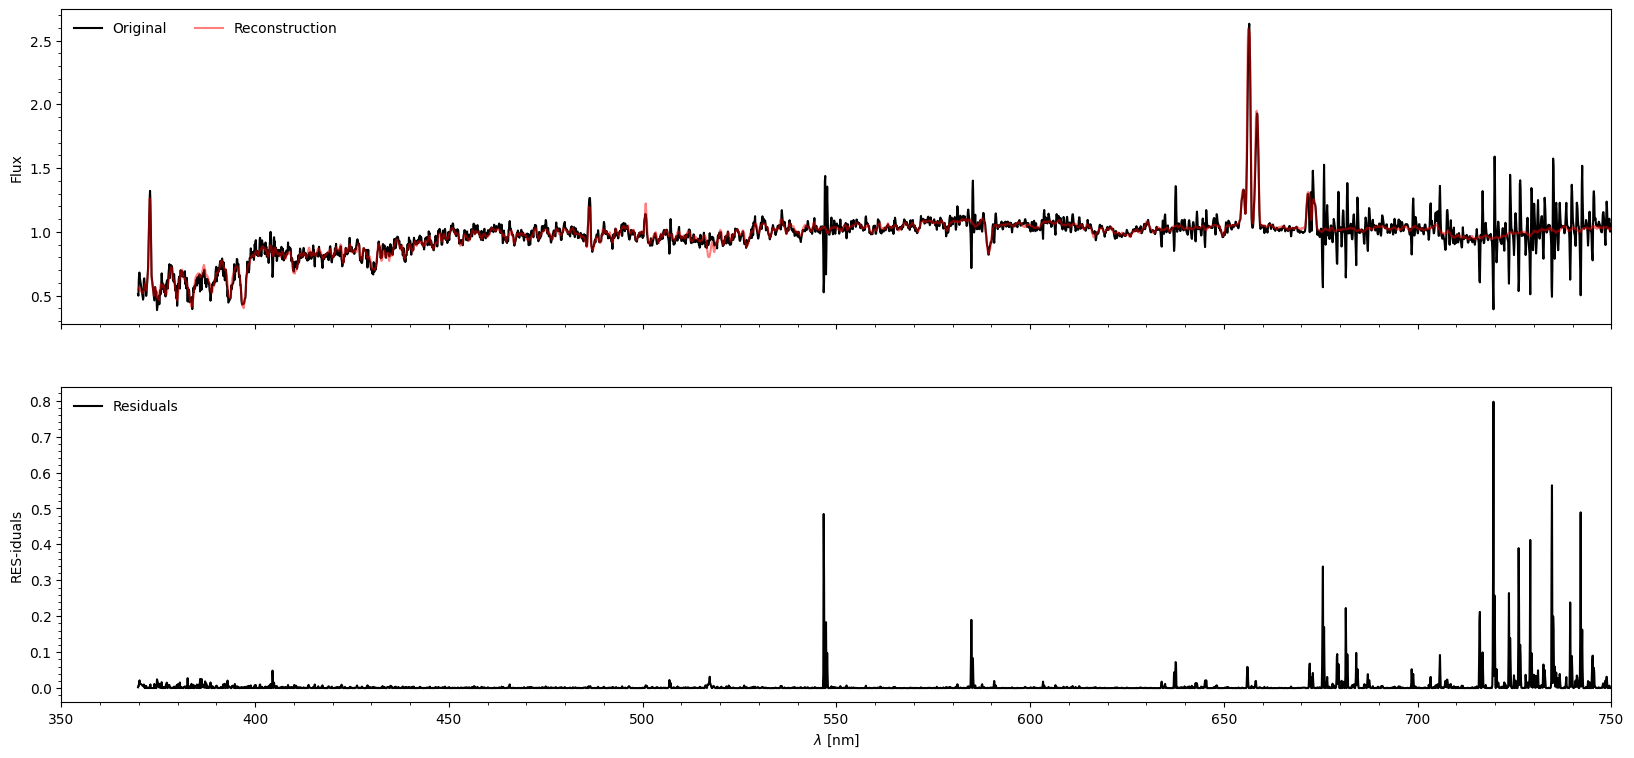

In [142]:
mask = score_rank_df.rank_mse_filter_250_rel == 1236
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 

rank_mse_rel                   1972.0
rank_mse_filter_250_rel        1273.0
rank_mse_97_rel               38688.0
rank_mse_filter_250_97_rel    35453.0
rank_mse                        275.0
rank_mse_filter_250             111.0
rank_mse_97                   43736.0
rank_mse_filter_250_97        34472.0
Name: 378459632399575040, dtype: float64

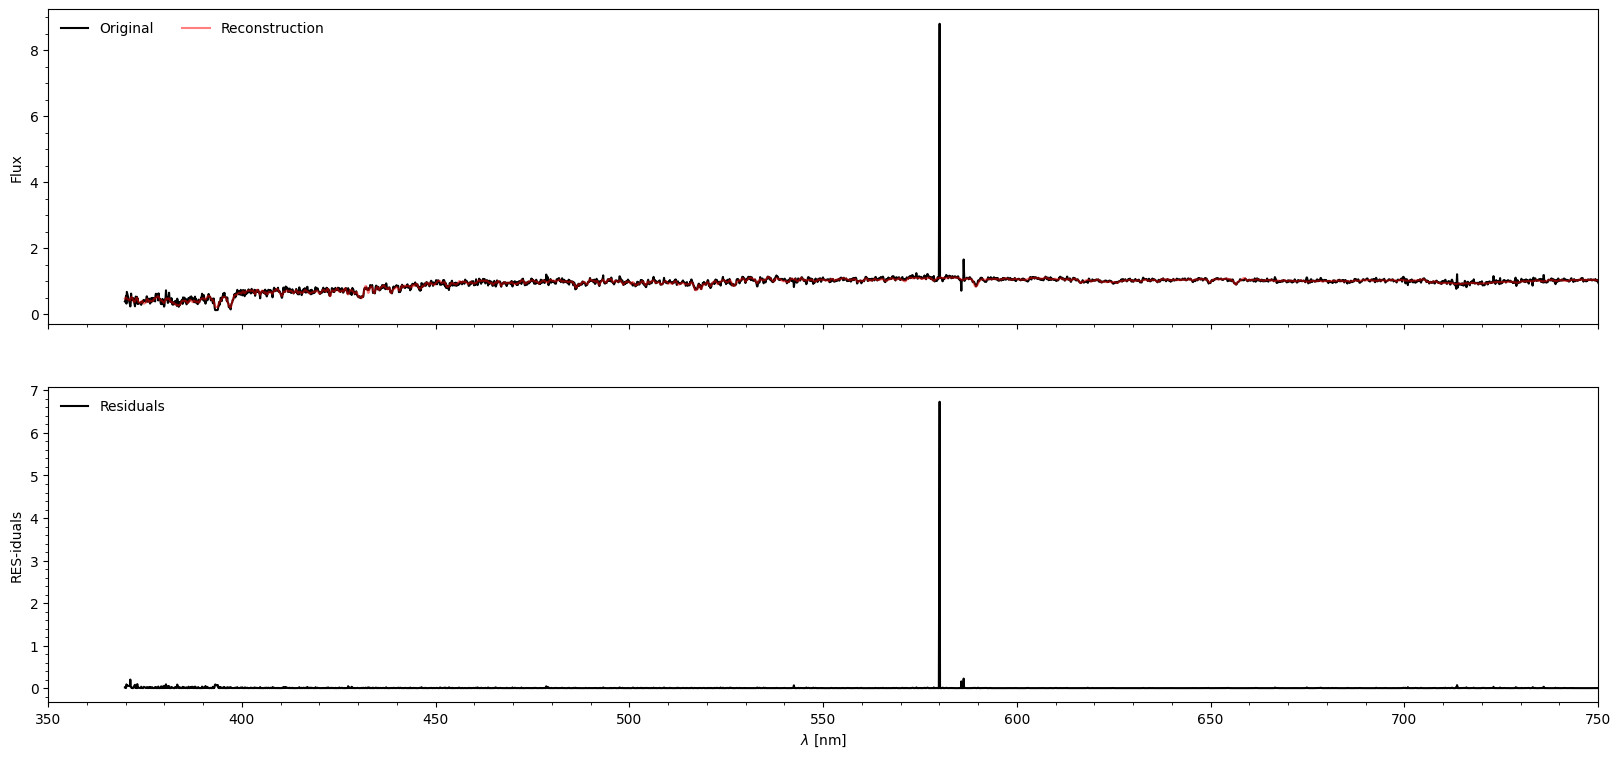

In [144]:
mask = score_rank_df.rank_mse_filter_250_rel == 1273
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 1323

rank_mse_rel                   1896.0
rank_mse_filter_250_rel        1323.0
rank_mse_97_rel               22123.0
rank_mse_filter_250_97_rel    19899.0
rank_mse                      26545.0
rank_mse_filter_250           19896.0
rank_mse_97                   39997.0
rank_mse_filter_250_97        38711.0
Name: 319786117589133312, dtype: float64

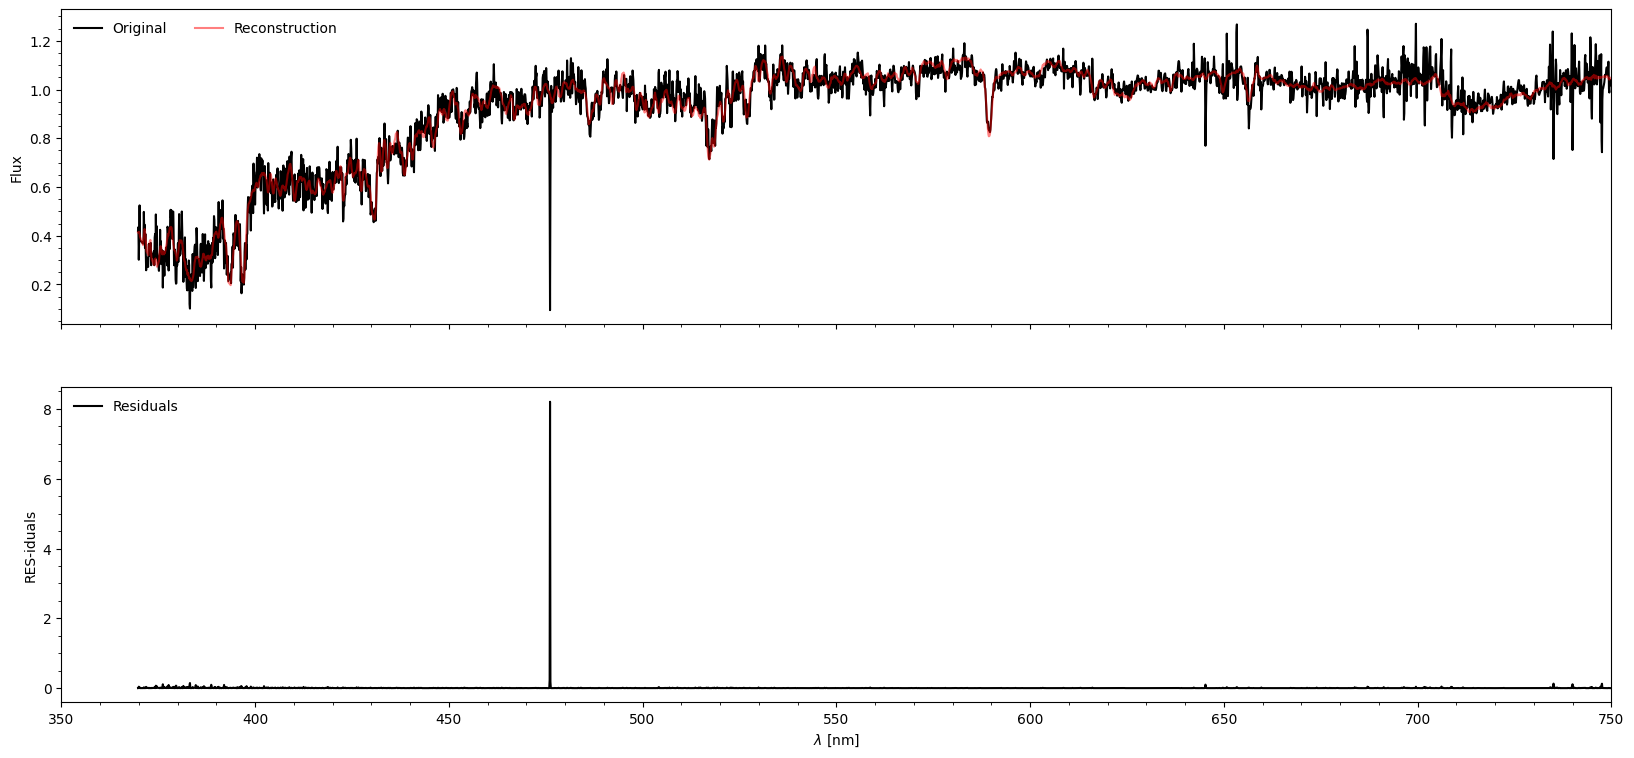

In [141]:
mask = score_rank_df.rank_mse_filter_250_rel == 1323
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 1566

rank_mse_rel                   2058.0
rank_mse_filter_250_rel        1566.0
rank_mse_97_rel                8425.0
rank_mse_filter_250_97_rel     1837.0
rank_mse                      32252.0
rank_mse_filter_250           50999.0
rank_mse_97                   69853.0
rank_mse_filter_250_97        78619.0
Name: 2823863958878840832, dtype: float64

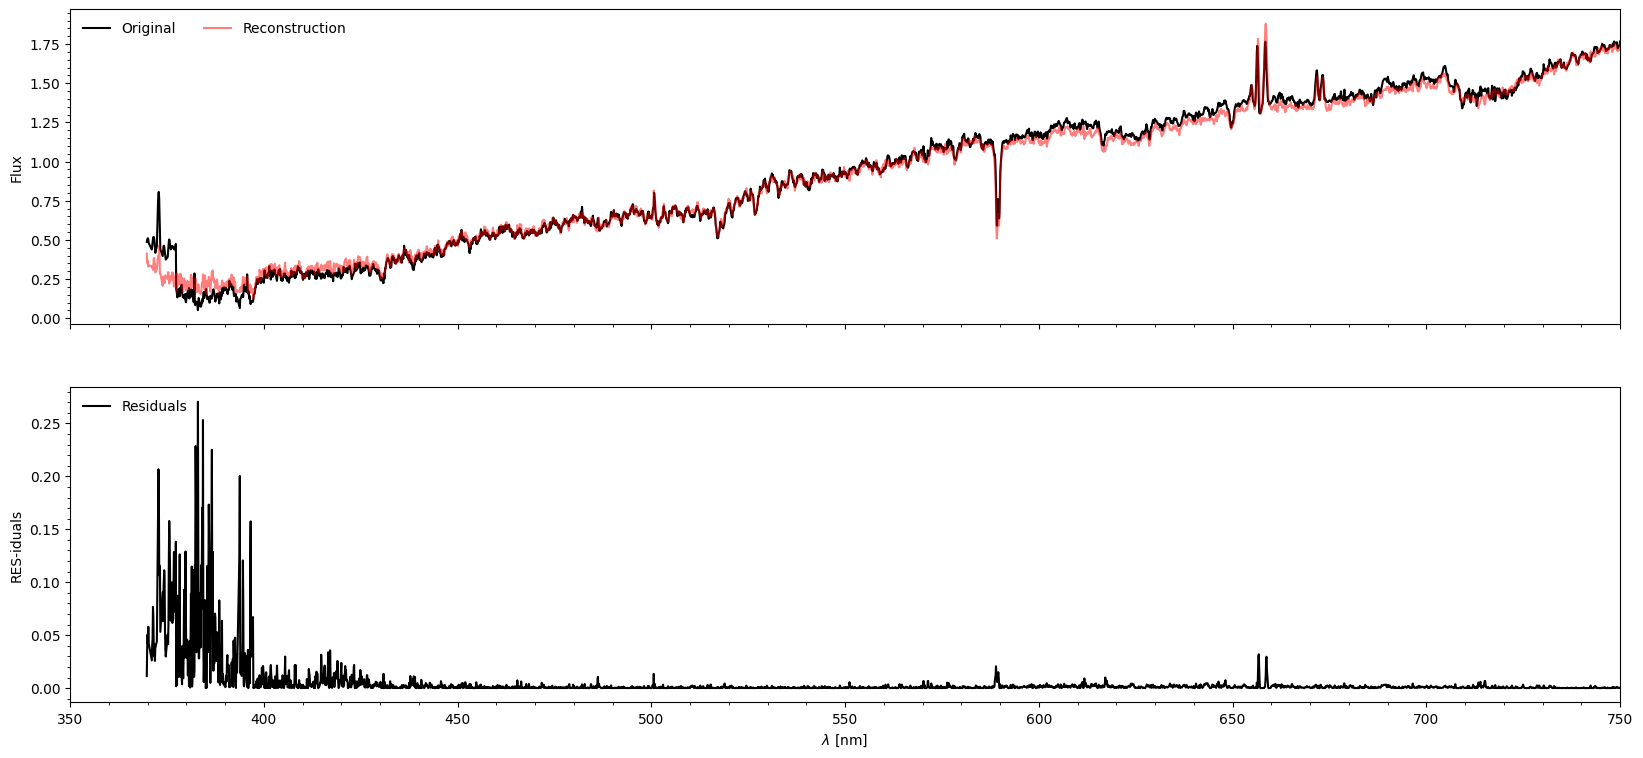

In [145]:
mask = score_rank_df.rank_mse_filter_250_rel == 1566
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

# Trim RSE

## Rank 666

rank_mse_rel                   2649.0
rank_mse_filter_250_rel        2750.0
rank_mse_97_rel                 666.0
rank_mse_filter_250_97_rel     4092.0
rank_mse                      55746.0
rank_mse_filter_250           48354.0
rank_mse_97                   29058.0
rank_mse_filter_250_97        63173.0
Name: 1781231151415846912, dtype: float64

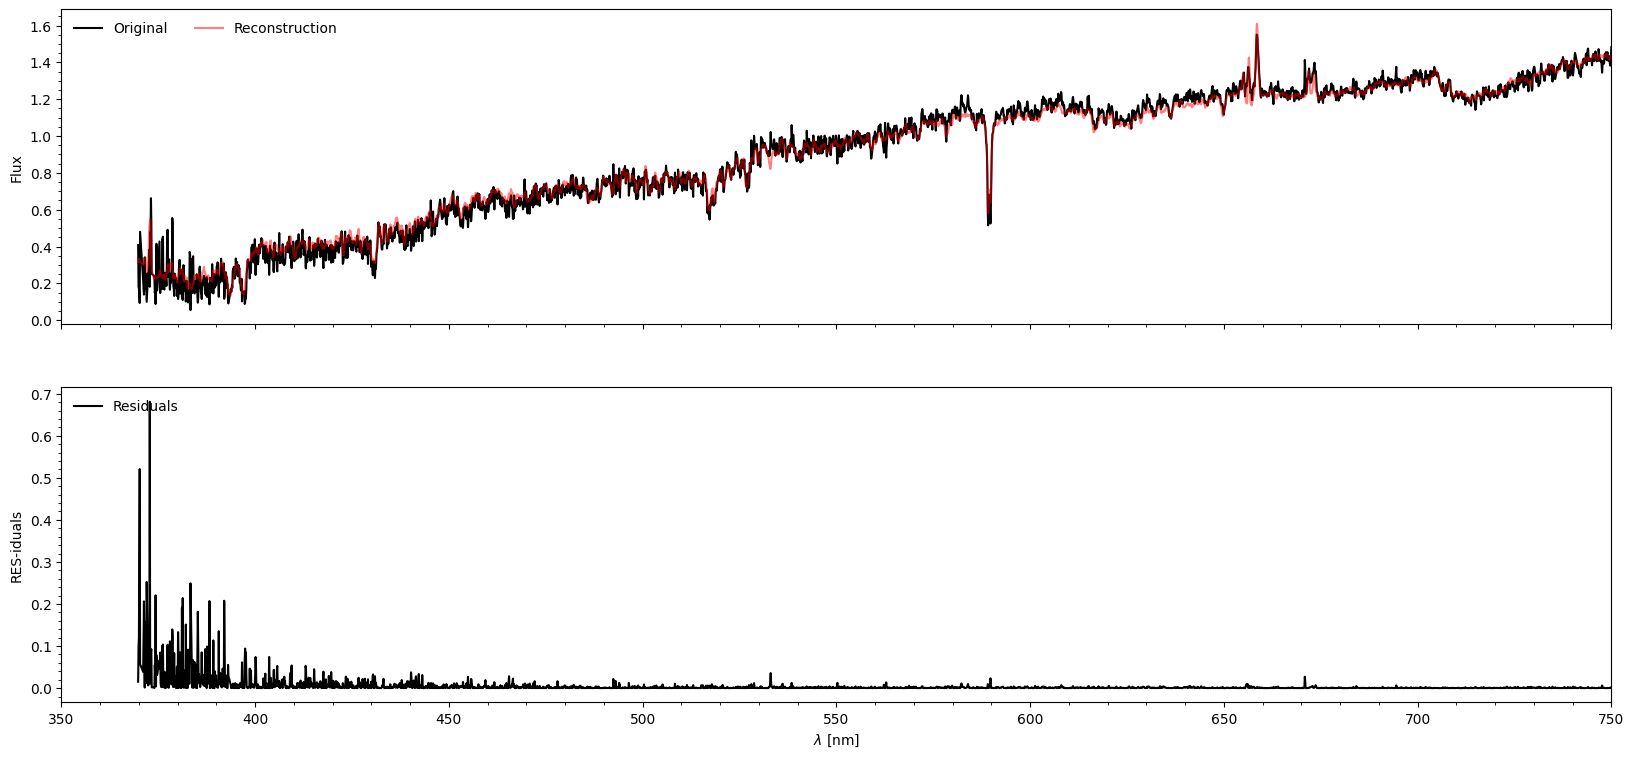

In [147]:
mask = score_rank_df.rank_mse_97_rel == 666
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 766

rank_mse_rel                  4235.0
rank_mse_filter_250_rel       3565.0
rank_mse_97_rel                766.0
rank_mse_filter_250_97_rel    2241.0
rank_mse                      2347.0
rank_mse_filter_250           1881.0
rank_mse_97                   1159.0
rank_mse_filter_250_97         910.0
Name: 511298502572140544, dtype: float64

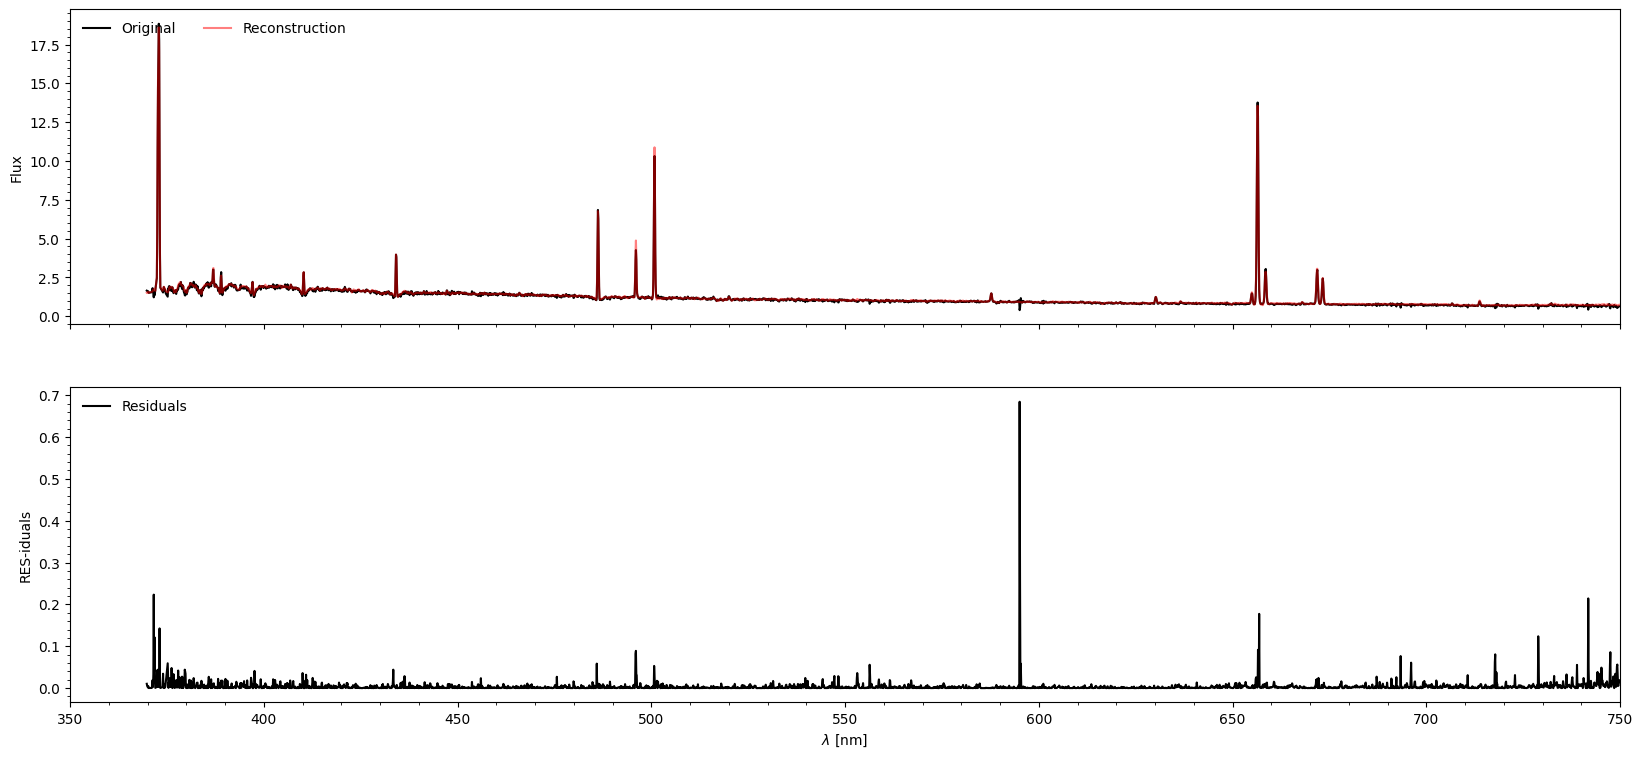

In [148]:
mask = score_rank_df.rank_mse_97_rel == 766
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 1064

rank_mse_rel                  3031.0
rank_mse_filter_250_rel       3585.0
rank_mse_97_rel               1054.0
rank_mse_filter_250_97_rel    1901.0
rank_mse                      4616.0
rank_mse_filter_250           2654.0
rank_mse_97                   1626.0
rank_mse_filter_250_97        1653.0
Name: 2725943656996431872, dtype: float64

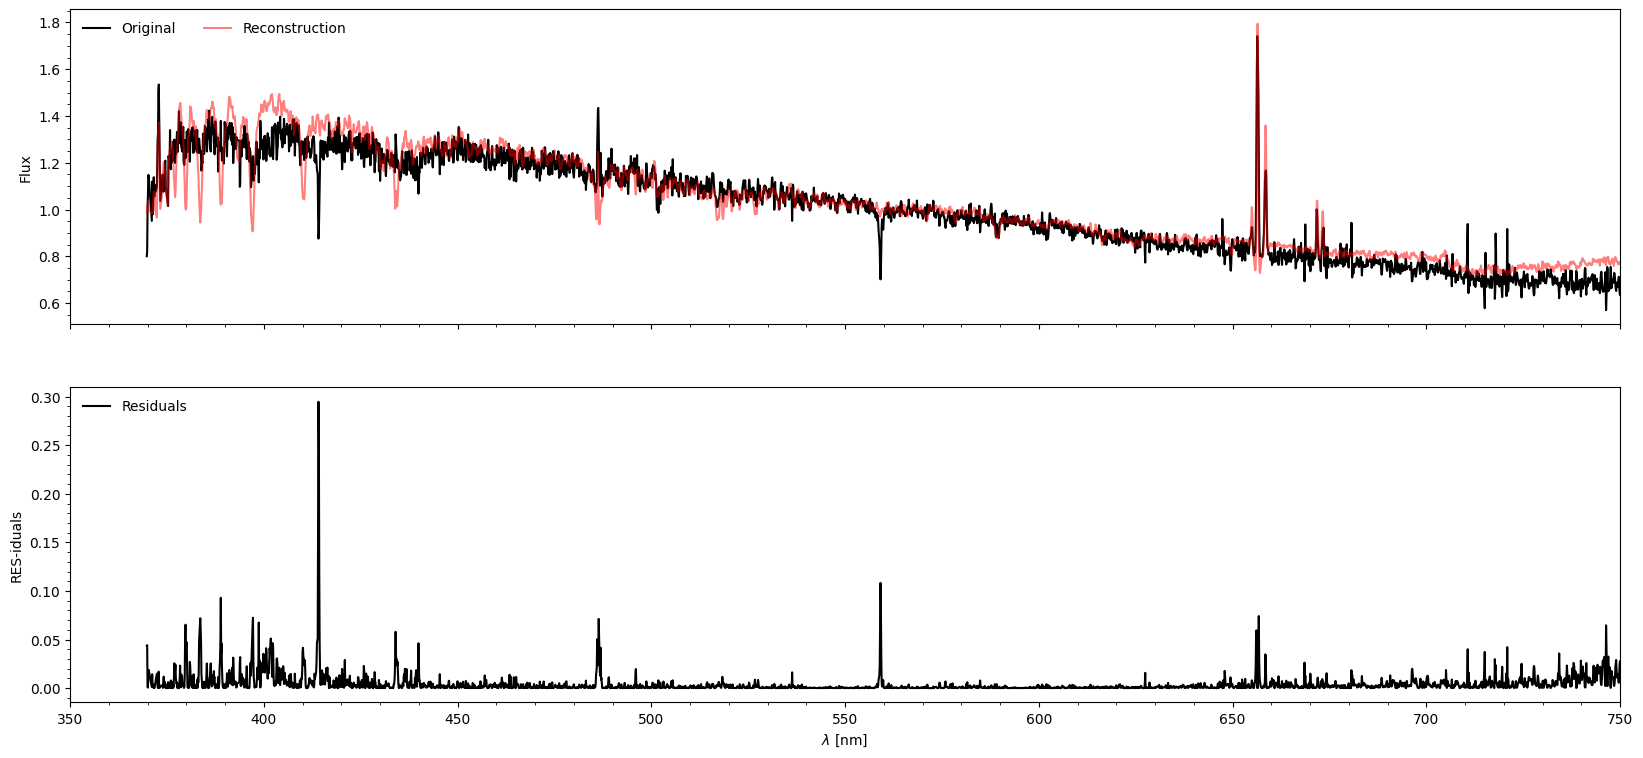

In [149]:
mask = score_rank_df.rank_mse_97_rel == 1054
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

## Rank 1064

rank_mse_rel                  2522.0
rank_mse_filter_250_rel       4477.0
rank_mse_97_rel               1064.0
rank_mse_filter_250_97_rel    2738.0
rank_mse                      2108.0
rank_mse_filter_250           2365.0
rank_mse_97                   1015.0
rank_mse_filter_250_97        1290.0
Name: 1647263633111017472, dtype: float64

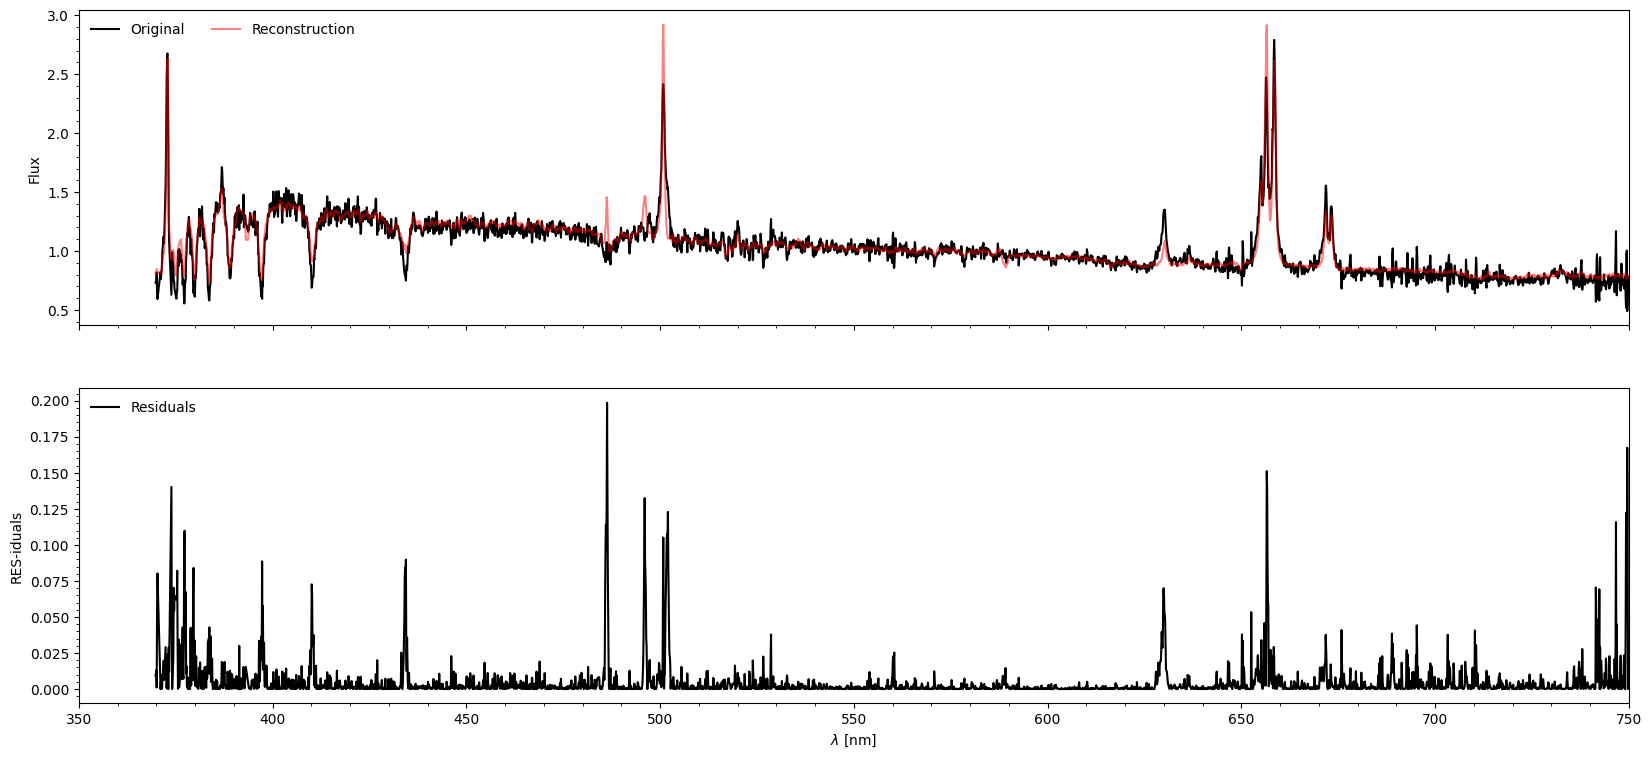

In [146]:
mask = score_rank_df.rank_mse_97_rel == 1064
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = res_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RESidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(20, 9)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T